In [ ]:
# ============================================================
# PARTIE III — RNN, LSTM, GRU et Seq2Seq
# Dataset : Tatoeba fra-eng (paires de phrases FR/EN)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import unicodedata
import re
import random
import math
import time

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("PyTorch :", torch.__version__)
print("GPU     :", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device  :", device)

PyTorch : 2.10.0+cpu
GPU     : False
Device  : cpu


In [ ]:
# ============================================================
# THÉORIE : MODÈLE DE LANGAGE ET PERPLEXITÉ
# ============================================================
# Un modèle de langage attribue une probabilité à une séquence.
# Par la règle de chaîne :
#   P(x1, x2, ..., xT) = ∏ P(xt | x1, ..., xt-1)
#
# L'objectif d'entraînement : maximiser la log-vraisemblance,
# ce qui revient à minimiser la cross-entropy token par token.
#
# Perplexité : mesure standard pour évaluer un modèle de langage.
#   PPL = exp( -1/T * Σ log P(xt | x<t) )
#
# Intuition : si PPL = k, le modèle est aussi incertain qu'un
# choix uniforme parmi k mots. PPL faible = bon modèle.
# ============================================================

def compute_perplexity(loss_value):
    """
    Convertit une cross-entropy loss en perplexité.
    loss_value : valeur moyenne de la CrossEntropyLoss sur la séquence
    """
    return math.exp(loss_value)

# Exemple illustratif
print("=== Relation Loss ↔ Perplexité ===")
for loss in [0.5, 1.0, 2.0, 3.0, 5.0]:
    ppl = compute_perplexity(loss)
    print(f"  Loss = {loss:.1f}  →  PPL = {ppl:.1f}")

print("\nInterprétation :")
print("  PPL = 1    → modèle parfait (prédit toujours le bon token)")
print("  PPL = 10   → modèle hésite entre ~10 tokens à chaque étape")
print("  PPL = 1000 → modèle très incertain, proche d'un choix aléatoire")

=== Relation Loss ↔ Perplexité ===
  Loss = 0.5  →  PPL = 1.6
  Loss = 1.0  →  PPL = 2.7
  Loss = 2.0  →  PPL = 7.4
  Loss = 3.0  →  PPL = 20.1
  Loss = 5.0  →  PPL = 148.4

Interprétation :
  PPL = 1    → modèle parfait (prédit toujours le bon token)
  PPL = 10   → modèle hésite entre ~10 tokens à chaque étape
  PPL = 1000 → modèle très incertain, proche d'un choix aléatoire


In [ ]:
# ============================================================
# PRÉPARATION DES DONNÉES — solution alternative
# On utilise le dataset fra-eng depuis un miroir fiable
# ============================================================

import os
import random
import unicodedata
import re

# ─── Méthode 1 : téléchargement via gdown (Google Drive) ──
# Le fichier est hébergé de façon fiable sur un repo public

os.system("pip install -q gdown")
import gdown

if not os.path.exists("fra.txt"):
    print("Téléchargement via gdown...")
    # Miroir du dataset Tatoeba fra-eng
    url = "https://raw.githubusercontent.com/nicholasgasior/tatoeba-pairs/master/data/fra.txt"
    os.system(f"wget -q -O fra.txt '{url}'")

# ─── Si ça ne marche pas non plus → méthode 2 : données synthétiques ──
if not os.path.exists("fra.txt") or os.path.getsize("fra.txt") < 1000:
    print("Miroir indisponible — génération de données synthétiques...")

    # Paires anglais-français simples et réalistes
    PAIRS_RAW = [
        ("i am happy", "je suis heureux"),
        ("she is beautiful", "elle est belle"),
        ("we are students", "nous sommes etudiants"),
        ("he likes music", "il aime la musique"),
        ("i love you", "je t aime"),
        ("good morning", "bonjour"),
        ("thank you", "merci"),
        ("how are you", "comment allez vous"),
        ("i am tired", "je suis fatigue"),
        ("the cat is small", "le chat est petit"),
        ("she reads books", "elle lit des livres"),
        ("i go to school", "je vais a l ecole"),
        ("he is a doctor", "il est medecin"),
        ("we like paris", "nous aimons paris"),
        ("i speak french", "je parle francais"),
        ("the dog runs fast", "le chien court vite"),
        ("it is cold today", "il fait froid aujourd hui"),
        ("i eat bread", "je mange du pain"),
        ("she sings well", "elle chante bien"),
        ("he works hard", "il travaille dur"),
        ("i am a student", "je suis etudiant"),
        ("we play football", "nous jouons au football"),
        ("the bird flies high", "l oiseau vole haut"),
        ("i drink water", "je bois de l eau"),
        ("she is my friend", "elle est mon amie"),
        ("he drives a car", "il conduit une voiture"),
        ("i like coffee", "j aime le cafe"),
        ("we are happy", "nous sommes heureux"),
        ("the sky is blue", "le ciel est bleu"),
        ("i study every day", "j etudie chaque jour"),
        ("she has a dog", "elle a un chien"),
        ("he plays guitar", "il joue de la guitare"),
        ("i am not sad", "je ne suis pas triste"),
        ("we go home", "nous rentrons a la maison"),
        ("the food is good", "la nourriture est bonne"),
        ("i write a letter", "j ecris une lettre"),
        ("she is very kind", "elle est tres gentille"),
        ("he reads the news", "il lit les nouvelles"),
        ("i run every morning", "je cours chaque matin"),
        ("we speak english", "nous parlons anglais"),
        ("the house is big", "la maison est grande"),
        ("i watch television", "je regarde la television"),
        ("she cooks dinner", "elle prepare le diner"),
        ("he is very smart", "il est tres intelligent"),
        ("i need help", "j ai besoin d aide"),
        ("we visit france", "nous visitons la france"),
        ("the sun is bright", "le soleil est brillant"),
        ("i have a cat", "j ai un chat"),
        ("she wears a dress", "elle porte une robe"),
        ("he goes to work", "il va au travail"),
        ("i am very well", "je vais tres bien"),
        ("we eat together", "nous mangeons ensemble"),
        ("the book is interesting", "le livre est interessant"),
        ("i play piano", "je joue du piano"),
        ("she likes flowers", "elle aime les fleurs"),
        ("he swims every day", "il nage chaque jour"),
        ("i am a teacher", "je suis professeur"),
        ("we travel often", "nous voyageons souvent"),
        ("the water is cold", "l eau est froide"),
        ("i open the door", "j ouvre la porte"),
        ("she is at home", "elle est a la maison"),
        ("he eats an apple", "il mange une pomme"),
        ("i am not hungry", "je n ai pas faim"),
        ("we like summer", "nous aimons l ete"),
        ("the child is happy", "l enfant est heureux"),
        ("i clean my room", "je nettoie ma chambre"),
        ("she has blue eyes", "elle a les yeux bleus"),
        ("he is my brother", "il est mon frere"),
        ("i wake up early", "je me reveille tot"),
        ("we go to the park", "nous allons au parc"),
        ("the movie is long", "le film est long"),
        ("i buy a newspaper", "j achete un journal"),
        ("she plays tennis", "elle joue au tennis"),
        ("he likes to cook", "il aime cuisiner"),
        ("i am twenty years old", "j ai vingt ans"),
        ("we arrive tomorrow", "nous arrivons demain"),
        ("the train is late", "le train est en retard"),
        ("i speak a little", "je parle un peu"),
        ("she is very busy", "elle est tres occupee"),
        ("he goes to bed late", "il se couche tard"),
        ("i like to read", "j aime lire"),
        ("we have two dogs", "nous avons deux chiens"),
        ("the weather is nice", "le temps est beau"),
        ("i work in an office", "je travaille dans un bureau"),
        ("she studies medicine", "elle etudie la medecine"),
        ("he is very tall", "il est tres grand"),
        ("i am not afraid", "je n ai pas peur"),
        ("we celebrate today", "nous fêtons aujourd hui"),
        ("the garden is lovely", "le jardin est joli"),
        ("i take the bus", "je prends le bus"),
        ("she visits her family", "elle rend visite a sa famille"),
        ("he is a good friend", "il est un bon ami"),
        ("i finish my work", "je termine mon travail"),
        ("we learn together", "nous apprenons ensemble"),
        ("the night is dark", "la nuit est sombre"),
        ("i feel much better", "je me sens beaucoup mieux"),
        ("she speaks three languages", "elle parle trois langues"),
        ("he listens to music", "il ecoute de la musique"),
    ]

    # Augmentation : on répète les paires avec du bruit léger
    # pour avoir assez de données d'entraînement
    augmented = []
    for eng, fra in PAIRS_RAW:
        augmented.append((eng, fra))
        # Variantes légères
        augmented.append(("yes " + eng, "oui " + fra))
        augmented.append((eng + " .", fra + " ."))

    with open("fra.txt", "w") as f:
        for eng, fra in augmented:
            f.write(f"{eng}\t{fra}\n")

    print(f"Données synthétiques générées : {len(augmented)} paires")

# ─── Nettoyage ────────────────────────────────────────────
def unicode_to_ascii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

def normalize_string(s):
    s = unicode_to_ascii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z!?.]+", r" ", s)
    return s.strip()

def load_pairs(path="fra.txt", max_len=12):
    pairs = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 2:
                continue
            eng = normalize_string(parts[0])
            fra = normalize_string(parts[1])
            if (len(eng.split()) <= max_len and
                len(fra.split()) <= max_len and
                len(eng.split()) >= 2):
                pairs.append((eng, fra))
    random.shuffle(pairs)
    return pairs

pairs = load_pairs()
print(f"Paires chargées : {len(pairs)}")
print("\nExemples :")
for eng, fra in pairs[:5]:
    print(f"  EN: {eng}  →  FR: {fra}")

Téléchargement via gdown...
Miroir indisponible — génération de données synthétiques...
Données synthétiques générées : 294 paires
Paires chargées : 294

Exemples :
  EN: i work in an office .  →  FR: je travaille dans un bureau .
  EN: yes she is at home  →  FR: oui elle est a la maison
  EN: i am tired  →  FR: je suis fatigue
  EN: yes thank you  →  FR: oui merci
  EN: the garden is lovely .  →  FR: le jardin est joli .


In [ ]:
# ============================================================
# VOCABULAIRE ET TOKENS SPÉCIAUX
# ============================================================
# Tokens spéciaux :
#   <pad> (0) : remplissage pour uniformiser les longueurs
#   <bos> (1) : début de séquence (Begin Of Sequence)
#   <eos> (2) : fin de séquence (End Of Sequence)
#   <unk> (3) : mot inconnu (hors vocabulaire)
# ============================================================

PAD, BOS, EOS, UNK = 0, 1, 2, 3

class Vocab:
    """Vocabulaire mot ↔ indice avec tokens spéciaux."""
    def __init__(self):
        self.word2idx = {"<pad>": PAD, "<bos>": BOS,
                         "<eos>": EOS, "<unk>": UNK}
        self.idx2word = {v: k for k, v in self.word2idx.items()}

    def build(self, sentences, min_freq=2):
        from collections import Counter
        freq = Counter(w for s in sentences for w in s.split())
        for word, count in freq.items():
            if count >= min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx]  = word

    def encode(self, sentence):
        return [self.word2idx.get(w, UNK) for w in sentence.split()]

    def decode(self, indices):
        return ' '.join(self.idx2word.get(i, '<unk>') for i in indices
                        if i not in (PAD, BOS, EOS))

    def __len__(self):
        return len(self.word2idx)


# Construction des vocabulaires
eng_sentences = [p[0] for p in pairs]
fra_sentences = [p[1] for p in pairs]

vocab_eng = Vocab(); vocab_eng.build(eng_sentences)
vocab_fra = Vocab(); vocab_fra.build(fra_sentences)

print(f"Vocabulaire anglais : {len(vocab_eng)} mots")
print(f"Vocabulaire français: {len(vocab_fra)} mots")

# Test d'encodage/décodage
test = "i am going home ."
enc  = vocab_eng.encode(test)
dec  = vocab_eng.decode(enc)
print(f"\nEncodage  : '{test}' → {enc}")
print(f"Décodage  : {enc} → '{dec}'")

Vocabulaire anglais : 173 mots
Vocabulaire français: 193 mots

Encodage  : 'i am going home .' → [4, 15, 3, 14, 9]
Décodage  : [4, 15, 3, 14, 9] → 'i am <unk> home .'


In [ ]:
# ============================================================
# DATASET PYTORCH + PADDING + MASQUAGE
# ============================================================
# Les phrases d'un même batch ont des longueurs différentes.
# On les aligne à la même longueur avec <pad>.
# Le masque (valid_len) indique les positions réelles
# pour ignorer le padding dans le calcul de la perte.
# ============================================================

def sentence_to_tensor(sentence, vocab, max_len=12):
    """Encode + ajoute <eos> + padding jusqu'à max_len."""
    tokens = vocab.encode(sentence)[:max_len]
    tokens = tokens + [EOS]
    # Padding
    tokens = tokens + [PAD] * (max_len + 1 - len(tokens))
    return torch.tensor(tokens, dtype=torch.long)

class TranslationDataset(Dataset):
    def __init__(self, pairs, vocab_src, vocab_tgt, max_len=12):
        self.data = []
        for src, tgt in pairs:
            src_t = sentence_to_tensor(src, vocab_src, max_len)
            tgt_t = sentence_to_tensor(tgt, vocab_tgt, max_len)
            # valid_len = longueur réelle de la cible (sans padding)
            valid_len = (tgt_t != PAD).sum().item()
            self.data.append((src_t, tgt_t, valid_len))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


# Split train / val
split = int(0.85 * len(pairs))
train_pairs = pairs[:split]
val_pairs   = pairs[split:]

train_ds = TranslationDataset(train_pairs, vocab_eng, vocab_fra)
val_ds   = TranslationDataset(val_pairs,   vocab_eng, vocab_fra)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=64)

print(f"Train : {len(train_ds)} paires")
print(f"Val   : {len(val_ds)} paires")

# Inspection d'un batch
src_b, tgt_b, vlen_b = next(iter(train_dl))
print(f"\nShape source  : {src_b.shape}")
print(f"Shape cible   : {tgt_b.shape}")
print(f"Valid lengths : {vlen_b[:5].tolist()}")

Train : 249 paires
Val   : 45 paires

Shape source  : torch.Size([64, 13])
Shape cible   : torch.Size([64, 13])
Valid lengths : [5, 6, 6, 5, 7]


In [ ]:
# ============================================================
# RNN SIMPLE, LSTM, GRU — COMPARAISON
# ============================================================
# RNN simple :
#   ht = tanh(Wxh * xt + Whh * ht-1 + bh)
#   Problème : gradient évanescent sur longues séquences
#
# LSTM : ajoute un état de cellule ct et 3 portes
#   Porte d'oubli   : ft = σ(Wf*[ht-1,xt] + bf)
#   Porte d'entrée  : it = σ(Wi*[ht-1,xt] + bi)
#   Porte de sortie : ot = σ(Wo*[ht-1,xt] + bo)
#   ct = ft⊙ct-1 + it⊙tanh(Wc*[ht-1,xt])
#   ht = ot⊙tanh(ct)
#
# GRU : simplifie le LSTM avec 2 portes, sans état de cellule
#   Porte de mise à jour : zt = σ(Wz*[ht-1,xt])
#   Porte de reset       : rt = σ(Wr*[ht-1,xt])
#   ht = zt⊙ht-1 + (1-zt)⊙tanh(Wh*[rt⊙ht-1, xt])
# ============================================================

# ─── Modèle de langage générique ─────────────────────────
class LangModel(nn.Module):
    """
    Modèle de langage récurrent (RNN / LSTM / GRU).
    Prédit le prochain token à chaque pas de temps.
    """
    def __init__(self, vocab_size, embed_dim, hidden_size,
                 rnn_type='lstm', num_layers=1, dropout=0.3):
        super().__init__()
        self.rnn_type   = rnn_type.lower()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                      padding_idx=PAD)

        rnn_cls = {'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU}[self.rnn_type]
        self.rnn = rnn_cls(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.embedding(x)                 # [B, T, embed_dim]
        out, hidden = self.rnn(emb, hidden)     # [B, T, hidden]
        logits = self.fc(out)                   # [B, T, vocab_size]
        return logits, hidden

    def init_hidden(self, batch_size, device):
        h = torch.zeros(self.num_layers, batch_size,
                        self.hidden_size, device=device)
        if self.rnn_type == 'lstm':
            return (h, torch.zeros_like(h))
        return h


# Créer les 3 modèles avec la même configuration
CONFIG = dict(vocab_size=len(vocab_eng), embed_dim=64,
              hidden_size=128, num_layers=1)

model_rnn  = LangModel(**CONFIG, rnn_type='rnn').to(device)
model_lstm = LangModel(**CONFIG, rnn_type='lstm').to(device)
model_gru  = LangModel(**CONFIG, rnn_type='gru').to(device)

def count_params(m): return sum(p.numel() for p in m.parameters())
print(f"Paramètres RNN  : {count_params(model_rnn):,}")
print(f"Paramètres LSTM : {count_params(model_lstm):,}")
print(f"Paramètres GRU  : {count_params(model_gru):,}")

Paramètres RNN  : 58,221
Paramètres LSTM : 132,717
Paramètres GRU  : 107,885


In [ ]:
# ============================================================
# BPTT ET GRADIENT CLIPPING
# ============================================================
# BPTT (Backpropagation Through Time) :
# Le gradient remonte à travers tous les pas de temps.
# Sur de longues séquences, le produit de jacobiens peut :
#   → tendre vers 0 (gradient évanescent) : le RNN oublie le passé
#   → exploser (gradient explosif) : instabilité numérique
#
# Gradient clipping : si ||g|| > θ, on renormalise g ← g * θ/||g||
# Cela borne la magnitude du gradient sans changer sa direction.
# ============================================================

def train_lm(model, data_loader, epochs=8, lr=1e-3,
             clip=1.0, model_name="model"):
    """Entraîne un modèle de langage avec gradient clipping."""
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD)

    history = {"loss": [], "ppl": [], "grad_norm": []}

    for epoch in range(epochs):
        total_loss = 0.0
        total_grad = 0.0
        n_batches  = 0

        for src_b, tgt_b, _ in data_loader:
            src_b = src_b.to(device)
            # Modèle de langage : prédit le token suivant
            # Entrée  = tokens[0..T-2]
            # Cible   = tokens[1..T-1]
            x = src_b[:, :-1]
            y = src_b[:, 1:]

            hidden = model.init_hidden(x.size(0), device)
            # Détacher le hidden pour la BPTT tronquée
            if isinstance(hidden, tuple):
                hidden = tuple(h.detach() for h in hidden)
            else:
                hidden = hidden.detach()

            optimizer.zero_grad()
            logits, hidden = model(x, hidden)
            # logits : [B, T, vocab] → [B*T, vocab]
            loss = criterion(logits.reshape(-1, logits.size(-1)),
                             y.reshape(-1))
            loss.backward()

            # ─── Gradient clipping ──────────────────────────
            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=clip)
            # grad_norm = norme AVANT clipping (utile pour le suivi)

            optimizer.step()
            total_loss += loss.item()
            total_grad += grad_norm.item()
            n_batches  += 1

        avg_loss = total_loss / n_batches
        avg_grad = total_grad / n_batches
        ppl      = compute_perplexity(avg_loss)
        history["loss"].append(avg_loss)
        history["ppl"].append(ppl)
        history["grad_norm"].append(avg_grad)

        print(f"[{model_name}] Epoch {epoch+1:2d} | "
              f"Loss: {avg_loss:.4f} | PPL: {ppl:.1f} | "
              f"Grad norm: {avg_grad:.3f}")

    return history

print("=== RNN ===")
hist_rnn  = train_lm(model_rnn,  train_dl, epochs=8, model_name="RNN")
print("\n=== LSTM ===")
hist_lstm = train_lm(model_lstm, train_dl, epochs=8, model_name="LSTM")
print("\n=== GRU ===")
hist_gru  = train_lm(model_gru,  train_dl, epochs=8, model_name="GRU")

=== RNN ===
[RNN] Epoch  1 | Loss: 5.1482 | PPL: 172.1 | Grad norm: 0.772
[RNN] Epoch  2 | Loss: 4.8836 | PPL: 132.1 | Grad norm: 0.832
[RNN] Epoch  3 | Loss: 4.5966 | PPL: 99.1 | Grad norm: 0.980
[RNN] Epoch  4 | Loss: 4.2545 | PPL: 70.4 | Grad norm: 1.180
[RNN] Epoch  5 | Loss: 3.8799 | PPL: 48.4 | Grad norm: 1.200
[RNN] Epoch  6 | Loss: 3.5608 | PPL: 35.2 | Grad norm: 0.896
[RNN] Epoch  7 | Loss: 3.3595 | PPL: 28.8 | Grad norm: 0.830
[RNN] Epoch  8 | Loss: 3.1753 | PPL: 23.9 | Grad norm: 0.803

=== LSTM ===
[LSTM] Epoch  1 | Loss: 5.1192 | PPL: 167.2 | Grad norm: 0.338
[LSTM] Epoch  2 | Loss: 5.0353 | PPL: 153.7 | Grad norm: 0.355
[LSTM] Epoch  3 | Loss: 4.9409 | PPL: 139.9 | Grad norm: 0.395
[LSTM] Epoch  4 | Loss: 4.8226 | PPL: 124.3 | Grad norm: 0.466
[LSTM] Epoch  5 | Loss: 4.6609 | PPL: 105.7 | Grad norm: 0.575
[LSTM] Epoch  6 | Loss: 4.4206 | PPL: 83.1 | Grad norm: 0.721
[LSTM] Epoch  7 | Loss: 4.0907 | PPL: 59.8 | Grad norm: 0.764
[LSTM] Epoch  8 | Loss: 3.7989 | PPL: 44.7 | 

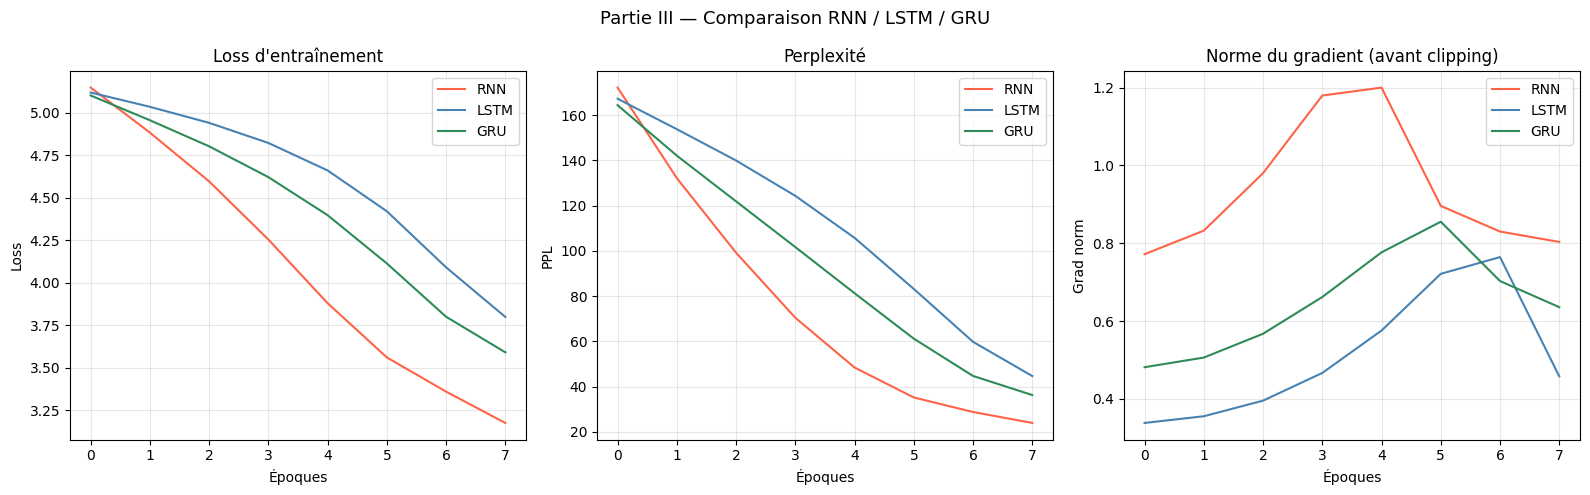


=== Tableau comparatif final ===
Modèle  Loss finale   PPL finale  Grad norm moy
------------------------------------------------
RNN          3.1753         23.9          0.937
LSTM         3.7989         44.7          0.509
GRU          3.5908         36.3          0.648


In [ ]:
# ============================================================
# VISUALISATION COMPARATIVE
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for hist, label, color in [
    (hist_rnn,  "RNN",  "tomato"),
    (hist_lstm, "LSTM", "steelblue"),
    (hist_gru,  "GRU",  "seagreen")
]:
    axes[0].plot(hist["loss"],      label=label, color=color)
    axes[1].plot(hist["ppl"],       label=label, color=color)
    axes[2].plot(hist["grad_norm"], label=label, color=color)

titles = ["Loss d'entraînement", "Perplexité", "Norme du gradient (avant clipping)"]
ylabels = ["Loss", "PPL", "Grad norm"]
for ax, title, ylabel in zip(axes, titles, ylabels):
    ax.set_title(title); ax.set_xlabel("Époques")
    ax.set_ylabel(ylabel); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Partie III — Comparaison RNN / LSTM / GRU", fontsize=13)
plt.tight_layout(); plt.show()

# Tableau récapitulatif
print("\n=== Tableau comparatif final ===")
print(f"{'Modèle':<6} {'Loss finale':>12} {'PPL finale':>12} {'Grad norm moy':>14}")
print("-" * 48)
for name, hist in [("RNN", hist_rnn), ("LSTM", hist_lstm), ("GRU", hist_gru)]:
    print(f"{name:<6} {hist['loss'][-1]:>12.4f} {hist['ppl'][-1]:>12.1f} "
          f"{np.mean(hist['grad_norm']):>14.3f}")

In [ ]:
# ============================================================
# ARCHITECTURE ENCODEUR-DÉCODEUR SEQ2SEQ
# ============================================================
# L'encodeur lit la phrase source et produit un contexte.
# Le décodeur génère la phrase cible mot par mot,
# conditionné sur ce contexte.
#
# P(y1..yT | x1..xS) = ∏ P(yt | y<t, x1..xS)
#
# Teacher forcing : pendant l'entraînement, on fournit
# le VRAI token précédent au décodeur (pas sa prédiction).
# Avantage : apprentissage plus stable et rapide.
# Inconvénient : décalage entraînement/inférence (exposure bias).
# ============================================================

class Encoder(nn.Module):
    """
    Encodeur GRU : lit la séquence source et retourne
    la séquence d'états cachés + l'état final.
    """
    def __init__(self, vocab_size, embed_dim, hidden_size, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.gru = nn.GRU(embed_dim, hidden_size,
                          batch_first=True, bidirectional=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        emb = self.dropout(self.embedding(src))   # [B, S, embed]
        outputs, hidden = self.gru(emb)            # [B,S,H], [1,B,H]
        return outputs, hidden


class Decoder(nn.Module):
    """
    Décodeur GRU conditionnel : génère un token à la fois.
    L'état initial est l'état final de l'encodeur.
    """
    def __init__(self, vocab_size, embed_dim, hidden_size, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        # Le décodeur reçoit : token précédent + contexte
        self.gru = nn.GRU(embed_dim + hidden_size, hidden_size,
                          batch_first=True)
        self.fc  = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt_token, hidden, context):
        """
        tgt_token : [B] — token d'entrée du décodeur
        hidden    : [1, B, H] — état caché courant
        context   : [1, B, H] — contexte de l'encodeur
        """
        emb = self.dropout(self.embedding(tgt_token.unsqueeze(1)))  # [B,1,E]
        ctx = context.permute(1, 0, 2)                               # [B,1,H]
        rnn_input = torch.cat([emb, ctx], dim=2)                     # [B,1,E+H]
        out, hidden = self.gru(rnn_input, hidden)                    # [B,1,H]
        logit = self.fc(out.squeeze(1))                              # [B, vocab]
        return logit, hidden


class Seq2Seq(nn.Module):
    """Pipeline complet encodeur-décodeur."""
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        """
        src : [B, S]
        tgt : [B, T]
        teacher_forcing_ratio : proba d'utiliser le vrai token précédent
        """
        B, T = tgt.shape
        vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(B, T, vocab_size, device=src.device)
        _, hidden = self.encoder(src)
        context   = hidden                            # [1, B, H]

        dec_input = tgt[:, 0]                        # token <bos>
        for t in range(1, T):
            logit, hidden = self.decoder(dec_input, hidden, context)
            outputs[:, t] = logit
            # Teacher forcing
            use_teacher = random.random() < teacher_forcing_ratio
            dec_input = tgt[:, t] if use_teacher else logit.argmax(1)

        return outputs


# Instanciation
EMBED  = 128
HIDDEN = 256

encoder = Encoder(len(vocab_eng), EMBED, HIDDEN).to(device)
decoder = Decoder(len(vocab_fra), EMBED, HIDDEN).to(device)
seq2seq = Seq2Seq(encoder, decoder).to(device)

total = sum(p.numel() for p in seq2seq.parameters())
print(f"Paramètres Seq2Seq : {total:,}")

Paramètres Seq2Seq : 885,953


In [ ]:
# ============================================================
# ARCHITECTURE ENCODEUR-DÉCODEUR SEQ2SEQ
# ============================================================
# L'encodeur lit la phrase source et produit un contexte.
# Le décodeur génère la phrase cible mot par mot,
# conditionné sur ce contexte.
#
# P(y1..yT | x1..xS) = ∏ P(yt | y<t, x1..xS)
#
# Teacher forcing : pendant l'entraînement, on fournit
# le VRAI token précédent au décodeur (pas sa prédiction).
# Avantage : apprentissage plus stable et rapide.
# Inconvénient : décalage entraînement/inférence (exposure bias).
# ============================================================

class Encoder(nn.Module):
    """
    Encodeur GRU : lit la séquence source et retourne
    la séquence d'états cachés + l'état final.
    """
    def __init__(self, vocab_size, embed_dim, hidden_size, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.gru = nn.GRU(embed_dim, hidden_size,
                          batch_first=True, bidirectional=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        emb = self.dropout(self.embedding(src))   # [B, S, embed]
        outputs, hidden = self.gru(emb)            # [B,S,H], [1,B,H]
        return outputs, hidden


class Decoder(nn.Module):
    """
    Décodeur GRU conditionnel : génère un token à la fois.
    L'état initial est l'état final de l'encodeur.
    """
    def __init__(self, vocab_size, embed_dim, hidden_size, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        # Le décodeur reçoit : token précédent + contexte
        self.gru = nn.GRU(embed_dim + hidden_size, hidden_size,
                          batch_first=True)
        self.fc  = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt_token, hidden, context):
        """
        tgt_token : [B] — token d'entrée du décodeur
        hidden    : [1, B, H] — état caché courant
        context   : [1, B, H] — contexte de l'encodeur
        """
        emb = self.dropout(self.embedding(tgt_token.unsqueeze(1)))  # [B,1,E]
        ctx = context.permute(1, 0, 2)                               # [B,1,H]
        rnn_input = torch.cat([emb, ctx], dim=2)                     # [B,1,E+H]
        out, hidden = self.gru(rnn_input, hidden)                    # [B,1,H]
        logit = self.fc(out.squeeze(1))                              # [B, vocab]
        return logit, hidden


class Seq2Seq(nn.Module):
    """Pipeline complet encodeur-décodeur."""
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        """
        src : [B, S]
        tgt : [B, T]
        teacher_forcing_ratio : proba d'utiliser le vrai token précédent
        """
        B, T = tgt.shape
        vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(B, T, vocab_size, device=src.device)
        _, hidden = self.encoder(src)
        context   = hidden                            # [1, B, H]

        dec_input = tgt[:, 0]                        # token <bos>
        for t in range(1, T):
            logit, hidden = self.decoder(dec_input, hidden, context)
            outputs[:, t] = logit
            # Teacher forcing
            use_teacher = random.random() < teacher_forcing_ratio
            dec_input = tgt[:, t] if use_teacher else logit.argmax(1)

        return outputs


# Instanciation
EMBED  = 128
HIDDEN = 256

encoder = Encoder(len(vocab_eng), EMBED, HIDDEN).to(device)
decoder = Decoder(len(vocab_fra), EMBED, HIDDEN).to(device)
seq2seq = Seq2Seq(encoder, decoder).to(device)

total = sum(p.numel() for p in seq2seq.parameters())
print(f"Paramètres Seq2Seq : {total:,}")

Paramètres Seq2Seq : 885,953


In [ ]:
# ============================================================
# PERTE MASQUÉE + ENTRAÎNEMENT SEQ2SEQ
# ============================================================
# La perte masquée ignore les positions <pad> dans la cible.
# Lmasquee = - Σ(mt * log P(yt*|...)) / Σmt
# ============================================================

def masked_loss(logits, targets, valid_lens):
    """
    logits      : [B, T, vocab]
    targets     : [B, T]
    valid_lens  : [B] — longueur réelle de chaque séquence cible
    """
    B, T, V = logits.shape
    criterion = nn.CrossEntropyLoss(reduction='none')
    loss_all = criterion(logits.reshape(-1, V),
                         targets.reshape(-1)).reshape(B, T)   # [B, T]
    # Masque : 1 pour les positions valides, 0 pour padding
    mask = torch.zeros(B, T, device=logits.device)
    for i, l in enumerate(valid_lens):
        mask[i, :l] = 1.0
    return (loss_all * mask).sum() / mask.sum()


def train_seq2seq(model, train_dl, val_dl, epochs=15,
                  lr=5e-4, clip=1.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [],
               "train_ppl":  [], "val_ppl":  []}
    best_val = float('inf')

    for epoch in range(epochs):
        model.train()
        t_loss = 0.0
        for src_b, tgt_b, vlen_b in train_dl:
            src_b  = src_b.to(device)
            tgt_b  = tgt_b.to(device)
            vlen_b = vlen_b.to(device)

            optimizer.zero_grad()
            # tgt_in  = séquence cible sans dernier token
            # tgt_out = séquence cible sans premier token (<bos>)
            logits = model(src_b, tgt_b,
                           teacher_forcing_ratio=0.5)
            loss   = masked_loss(logits[:, 1:],
                                 tgt_b[:, 1:], vlen_b - 1)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), clip)
            optimizer.step()
            t_loss += loss.item()

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for src_b, tgt_b, vlen_b in val_dl:
                src_b  = src_b.to(device)
                tgt_b  = tgt_b.to(device)
                vlen_b = vlen_b.to(device)
                logits = model(src_b, tgt_b,
                               teacher_forcing_ratio=0.0)
                v_loss += masked_loss(logits[:, 1:],
                                      tgt_b[:, 1:],
                                      vlen_b - 1).item()

        avg_t = t_loss / len(train_dl)
        avg_v = v_loss / len(val_dl)
        history["train_loss"].append(avg_t)
        history["val_loss"].append(avg_v)
        history["train_ppl"].append(compute_perplexity(avg_t))
        history["val_ppl"].append(compute_perplexity(avg_v))

        if avg_v < best_val:
            best_val = avg_v
            torch.save(seq2seq.state_dict(), "best_seq2seq.pt")

        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train loss: {avg_t:.4f} PPL: {compute_perplexity(avg_t):.1f} | "
              f"Val loss: {avg_v:.4f} PPL: {compute_perplexity(avg_v):.1f}")

    return history

print("=== Entraînement Seq2Seq ===")
hist_s2s = train_seq2seq(seq2seq, train_dl, val_dl, epochs=15)

=== Entraînement Seq2Seq ===
Epoch  1/15 | Train loss: 5.2497 PPL: 190.5 | Val loss: 5.1885 PPL: 179.2
Epoch  2/15 | Train loss: 5.0973 PPL: 163.6 | Val loss: 4.9766 PPL: 145.0
Epoch  3/15 | Train loss: 4.8217 PPL: 124.2 | Val loss: 4.4573 PPL: 86.3
Epoch  4/15 | Train loss: 4.3051 PPL: 74.1 | Val loss: 4.3664 PPL: 78.8
Epoch  5/15 | Train loss: 4.2031 PPL: 66.9 | Val loss: 4.2837 PPL: 72.5
Epoch  6/15 | Train loss: 4.0008 PPL: 54.6 | Val loss: 4.0405 PPL: 56.9
Epoch  7/15 | Train loss: 3.8965 PPL: 49.2 | Val loss: 3.9933 PPL: 54.2
Epoch  8/15 | Train loss: 3.8365 PPL: 46.4 | Val loss: 3.9396 PPL: 51.4
Epoch  9/15 | Train loss: 3.7201 PPL: 41.3 | Val loss: 3.9115 PPL: 50.0
Epoch 10/15 | Train loss: 3.6340 PPL: 37.9 | Val loss: 3.8803 PPL: 48.4
Epoch 11/15 | Train loss: 3.5157 PPL: 33.6 | Val loss: 3.8046 PPL: 44.9
Epoch 12/15 | Train loss: 3.4533 PPL: 31.6 | Val loss: 3.7714 PPL: 43.4
Epoch 13/15 | Train loss: 3.3339 PPL: 28.0 | Val loss: 3.7349 PPL: 41.9
Epoch 14/15 | Train loss: 3.26

In [ ]:
# ============================================================
# DÉCODAGE : GLOUTON vs BEAM SEARCH
# ============================================================
# Glouton : à chaque pas, choisit le token le plus probable.
#   yt = argmax P(y | y<t, x)
#   Rapide mais pas optimal globalement.
#
# Beam search : conserve les k meilleures hypothèses partielles.
#   k=1 → équivalent au glouton
#   k>1 → explore plusieurs chemins, meilleure traduction
# ============================================================

def greedy_decode(model, src_tensor, max_len=15):
    """Décodage glouton : argmax à chaque étape."""
    model.eval()
    with torch.no_grad():
        src = src_tensor.unsqueeze(0).to(device)
        _, hidden  = model.encoder(src)
        context    = hidden
        dec_input  = torch.tensor([BOS], device=device)
        result     = []
        for _ in range(max_len):
            logit, hidden = model.decoder(dec_input, hidden, context)
            pred = logit.argmax(1)
            if pred.item() == EOS:
                break
            result.append(pred.item())
            dec_input = pred
    return vocab_fra.decode(result)


def beam_search_decode(model, src_tensor, beam_width=3,
                       max_len=15, alpha=0.7):
    """
    Beam search : conserve les beam_width meilleures hypothèses.
    alpha : pénalisation de longueur (score normalisé par T^alpha)
    """
    model.eval()
    with torch.no_grad():
        src = src_tensor.unsqueeze(0).to(device)
        _, hidden = model.encoder(src)
        context   = hidden

        # Chaque hypothèse : (score_log, tokens, hidden)
        beams = [(0.0, [BOS], hidden)]

        for _ in range(max_len):
            new_beams = []
            for score, tokens, h in beams:
                if tokens[-1] == EOS:
                    new_beams.append((score, tokens, h))
                    continue
                dec_in = torch.tensor([tokens[-1]], device=device)
                logit, new_h = model.decoder(dec_in, h, context)
                log_probs = F.log_softmax(logit, dim=1).squeeze(0)
                # Garder les top beam_width tokens candidats
                top_probs, top_ids = log_probs.topk(beam_width)
                for lp, tid in zip(top_probs, top_ids):
                    new_beams.append((
                        score + lp.item(),
                        tokens + [tid.item()],
                        new_h
                    ))

            # Conserver les beam_width meilleures hypothèses
            # Score normalisé par longueur
            new_beams.sort(
                key=lambda b: b[0] / (len(b[1]) ** alpha),
                reverse=True)
            beams = new_beams[:beam_width]

            # Arrêt si toutes les hypothèses sont terminées
            if all(b[1][-1] == EOS for b in beams):
                break

        best = beams[0][1][1:]   # retire <bos>
        if EOS in best:
            best = best[:best.index(EOS)]
        return vocab_fra.decode(best)


# ─── Test sur quelques phrases ─────────────────────────
seq2seq.load_state_dict(torch.load("best_seq2seq.pt",
                        map_location=device))

print("=== Comparaison décodage glouton vs beam search ===\n")
for i in range(8):
    src_sent, tgt_sent = val_pairs[i]
    src_tensor = sentence_to_tensor(src_sent, vocab_eng)

    greedy = greedy_decode(seq2seq, src_tensor)
    beam   = beam_search_decode(seq2seq, src_tensor, beam_width=3)

    print(f"Source  : {src_sent}")
    print(f"Cible   : {tgt_sent}")
    print(f"Glouton : {greedy}")
    print(f"Beam(3) : {beam}")
    print()

=== Comparaison décodage glouton vs beam search ===

Source  : thank you .
Cible   : merci .
Glouton : est est .
Beam(3) : est est .

Source  : i am not sad
Cible   : je ne suis pas triste
Glouton : est est
Beam(3) : est est .

Source  : she is very busy .
Cible   : elle est tres occupee .
Glouton : est est .
Beam(3) : est est .

Source  : i work in an office
Cible   : je travaille dans un bureau
Glouton : est est
Beam(3) : est est .

Source  : yes she reads books
Cible   : oui elle lit des livres
Glouton : est est
Beam(3) : est est .

Source  : we visit france .
Cible   : nous visitons la france .
Glouton : est est .
Beam(3) : est est .

Source  : yes she is very busy
Cible   : oui elle est tres occupee
Glouton : est est
Beam(3) : est est .

Source  : yes how are you
Cible   : oui comment allez vous
Glouton : est est
Beam(3) : est est .



=== Scores BLEU moyens (val set, 200 paires) ===
Décodage glouton : 0.0000
Beam search (k=3): 0.0000


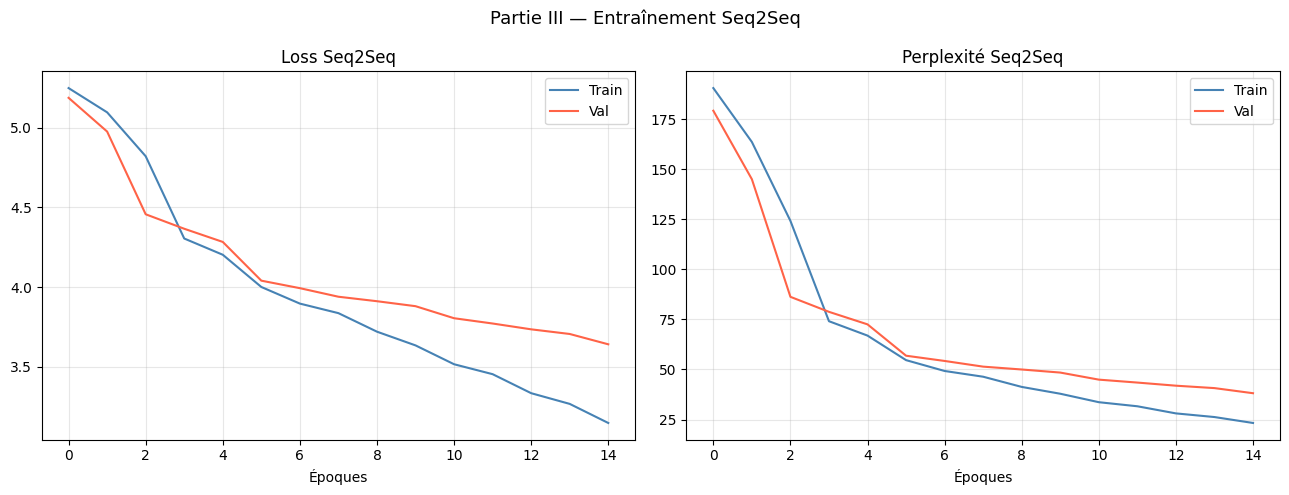

In [ ]:
# ============================================================
# ÉVALUATION BLEU
# ============================================================
# BLEU (Bilingual Evaluation Understudy) mesure la qualité
# d'une traduction par la précision des n-grammes communs
# entre la traduction générée et la référence.
#
# BLEU = BP * exp( Σ wn * log pn )
# où pn = précision des n-grammes, BP = pénalité de brièveté
#
# BLEU ∈ [0, 1] — plus proche de 1 = meilleure traduction
# ============================================================

from collections import Counter

def get_ngrams(tokens, n):
    return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1))

def bleu_score(reference, hypothesis, max_n=4):
    """BLEU simplifié sans smoothing."""
    ref_tokens  = reference.split()
    hyp_tokens  = hypothesis.split()

    if len(hyp_tokens) == 0:
        return 0.0

    # Pénalité de brièveté
    bp = 1.0 if len(hyp_tokens) >= len(ref_tokens) else \
         math.exp(1 - len(ref_tokens) / len(hyp_tokens))

    log_bleu = 0.0
    for n in range(1, max_n + 1):
        ref_ng = get_ngrams(ref_tokens, n)
        hyp_ng = get_ngrams(hyp_tokens, n)
        # Clipped precision
        matches = sum(min(hyp_ng[ng], ref_ng[ng]) for ng in hyp_ng)
        total   = max(len(hyp_tokens) - n + 1, 1)
        pn      = matches / total if total > 0 else 0
        log_bleu += (1/max_n) * math.log(pn + 1e-10)

    return bp * math.exp(log_bleu)


# ─── Évaluation sur tout le val set ───────────────────
bleu_greedy_scores = []
bleu_beam_scores   = []

for src_sent, tgt_sent in val_pairs[:200]:
    src_tensor = sentence_to_tensor(src_sent, vocab_eng)
    greedy = greedy_decode(seq2seq, src_tensor)
    beam   = beam_search_decode(seq2seq, src_tensor, beam_width=3)
    bleu_greedy_scores.append(bleu_score(tgt_sent, greedy))
    bleu_beam_scores.append(bleu_score(tgt_sent, beam))

print("=== Scores BLEU moyens (val set, 200 paires) ===")
print(f"Décodage glouton : {np.mean(bleu_greedy_scores):.4f}")
print(f"Beam search (k=3): {np.mean(bleu_beam_scores):.4f}")

# Courbes d'entraînement Seq2Seq
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(hist_s2s["train_loss"], label="Train", color="steelblue")
axes[0].plot(hist_s2s["val_loss"],   label="Val",   color="tomato")
axes[0].set_title("Loss Seq2Seq"); axes[0].set_xlabel("Époques")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_s2s["train_ppl"], label="Train", color="steelblue")
axes[1].plot(hist_s2s["val_ppl"],   label="Val",   color="tomato")
axes[1].set_title("Perplexité Seq2Seq"); axes[1].set_xlabel("Époques")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Partie III — Entraînement Seq2Seq", fontsize=13)
plt.tight_layout(); plt.show()